In [1]:
import pandas as pd

df_rb = pd.read_csv("../data/processed/rb_combined_training.csv")

print(df_rb.shape)
print(df_rb.dtypes)
print(df_rb.head())

(2121, 24)
player_id                      object
player_display_name            object
season                          int64
games                           int64
overall                       float64
round                         float64
pick                          float64
height                        float64
weight                        float64
pre_draft_ranking             float64
pre_draft_position_ranking    float64
pre_draft_grade               float64
carries_pg                    float64
rushing_yards_pg              float64
rushing_tds_pg                float64
receptions_pg                 float64
receiving_yards_pg            float64
receiving_tds_pg              float64
fumble_recovery_own_pg        float64
rushing_fumbles_lost_pg       float64
rushing_fumbles_pg            float64
target_fp_ppr                 float64
target_games                    int64
college_flag                    int64
dtype: object
    player_id player_display_name  season  games  overall  roun

In [2]:
from sklearn.model_selection import StratifiedKFold

# Drop ID/tracking columns, separate target
X_rb = df_rb.drop(columns=["player_id", "player_display_name", "season", 
                             "target_fp_ppr", "target_games", "games"])
y_rb = df_rb["target_fp_ppr"]
strat_rb = df_rb["college_flag"]

kf_rb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_indices_rb = list(kf_rb.split(X_rb, strat_rb))

# Verify fold composition
for fold, (train_idx, val_idx) in enumerate(cv_indices_rb):
    train_college = strat_rb.iloc[train_idx].sum()
    val_college = strat_rb.iloc[val_idx].sum()
    print(f"Fold {fold+1} | Train: {len(train_idx)} rows ({train_college} college) | Val: {len(val_idx)} rows ({val_college} college)")

Fold 1 | Train: 1696 rows (316 college) | Val: 425 rows (80 college)
Fold 2 | Train: 1697 rows (317 college) | Val: 424 rows (79 college)
Fold 3 | Train: 1697 rows (317 college) | Val: 424 rows (79 college)
Fold 4 | Train: 1697 rows (317 college) | Val: 424 rows (79 college)
Fold 5 | Train: 1697 rows (317 college) | Val: 424 rows (79 college)


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid_rf = {
    "n_estimators": [300, 500, 750],
    "max_features": ["sqrt", 0.4, 0.6],
    "min_samples_leaf": [2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_depth": [None, 10, 20, 30]
}

param_grid_xgb = {
    "n_estimators": [300, 500, 750],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5]
}

# RF search
rf_rb = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=40, scoring="neg_root_mean_squared_error",
    cv=cv_indices_rb, random_state=42, n_jobs=-1, verbose=1
)
rf_rb.fit(X_rb, y_rb)

# XGBoost search
xgb_rb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid_xgb,
    n_iter=40, scoring="neg_root_mean_squared_error",
    cv=cv_indices_rb, random_state=42, n_jobs=-1, verbose=1
)
xgb_rb.fit(X_rb, y_rb)

print("\n--- RB Model Comparison ---")
print(f"Random Forest RMSE: {-rf_rb.best_score_:.4f}")
print(f"XGBoost RMSE:       {-xgb_rb.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- RB Model Comparison ---
Random Forest RMSE: 3.7714
XGBoost RMSE:       3.7839


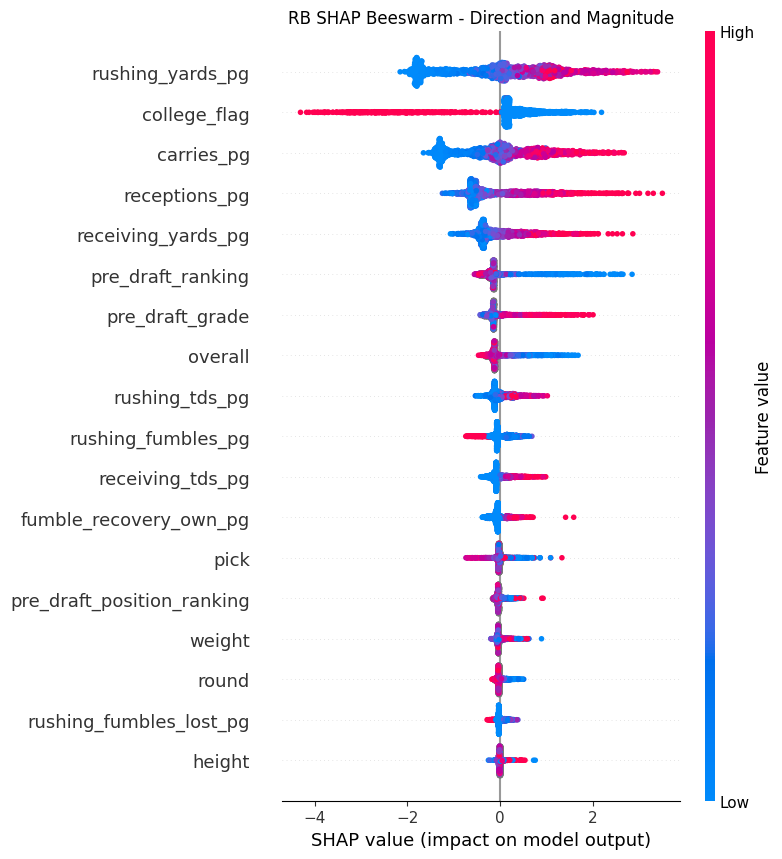

RB model saved
Features: ['overall', 'round', 'pick', 'height', 'weight', 'pre_draft_ranking', 'pre_draft_position_ranking', 'pre_draft_grade', 'carries_pg', 'rushing_yards_pg', 'rushing_tds_pg', 'receptions_pg', 'receiving_yards_pg', 'receiving_tds_pg', 'fumble_recovery_own_pg', 'rushing_fumbles_lost_pg', 'rushing_fumbles_pg', 'college_flag']


In [4]:
import shap
import matplotlib.pyplot as plt
import joblib
import json

# Fit best RF on full data
best_rf_rb = rf_rb.best_estimator_
best_rf_rb.fit(X_rb, y_rb)

# SHAP
explainer_rb = shap.TreeExplainer(best_rf_rb)
shap_values_rb = explainer_rb.shap_values(X_rb)

# Beeswarm plot
shap.summary_plot(shap_values_rb, X_rb, show=False)
plt.title("RB SHAP Beeswarm - Direction and Magnitude")
plt.tight_layout()
plt.show()

# Save model and feature list
joblib.dump(best_rf_rb, "best_rf_rb_model.joblib")
feature_cols_rb = X_rb.columns.tolist()
with open("rf_rb_feature_cols.json", "w") as f:
    json.dump(feature_cols_rb, f)

print("RB model saved")
print("Features:", feature_cols_rb)